# PCA

## imports

In [61]:
import scipy.io
import matplotlib.pyplot as plt
from matplotlib import pyplot
import plotly.graph_objects as go
from sklearn.decomposition import PCA

## PCA for ellipsoide

### Prepare data

In [62]:
# Load the data
mat_ellips = scipy.io.loadmat('datasets/datasets/ellipsoide_standardpca.mat')
X_ellips = mat_ellips['X']
n = X_ellips.shape[0]
d = X_ellips.shape[1]

print('n,d:',n,d)

n,d: 1000 100


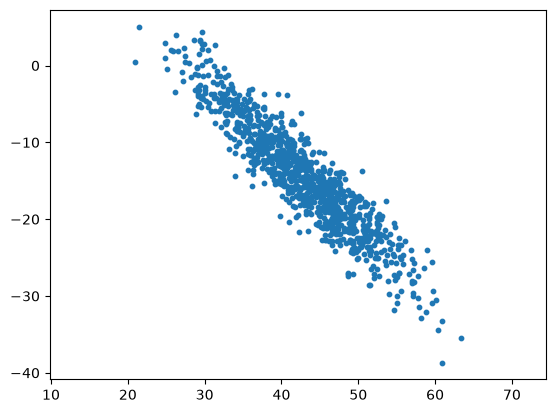

In [63]:
# Plot the data
plt.scatter(X_ellips[:,0], X_ellips[:,1], s=10)
plt.axis('equal')
plt.show()

###  Run (standard) Linear PCA

In [64]:
# Compute PCA
pca_ellips = PCA(n_components=2)
pca_ellips.fit(X_ellips)
print('pca.singular_values_:',pca_ellips.singular_values_)

pca.singular_values_: [309.93602651  61.35551958]


### Show axis

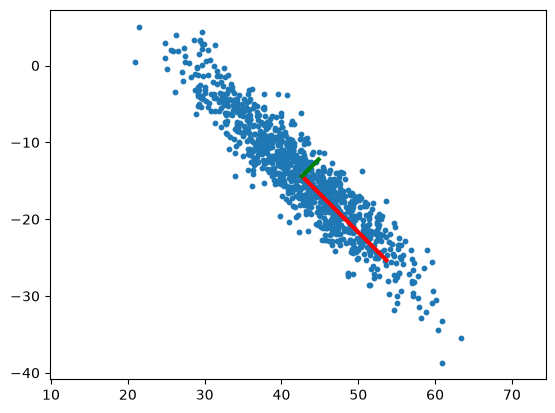

In [65]:
# Plot the data and the principal components centerd at the mean
plt.scatter(X_ellips[:,0], X_ellips[:,1], s=10)
plt.axis('equal')
ratio = 20
colors = ['red', 'green']  # Liste de couleurs à utiliser
for dim in range(2):
    plt.plot([pca_ellips.mean_[0], pca_ellips.mean_[0] + pca_ellips.components_[dim,0]*pca_ellips.singular_values_[dim]/ratio], [pca_ellips.mean_[1], pca_ellips.mean_[1] + pca_ellips.components_[dim,1]*pca_ellips.singular_values_[dim]/ratio], color=colors[dim], linewidth=3)

plt.show()

### Reproject dataset

X_proj.shape: (1000, 2)


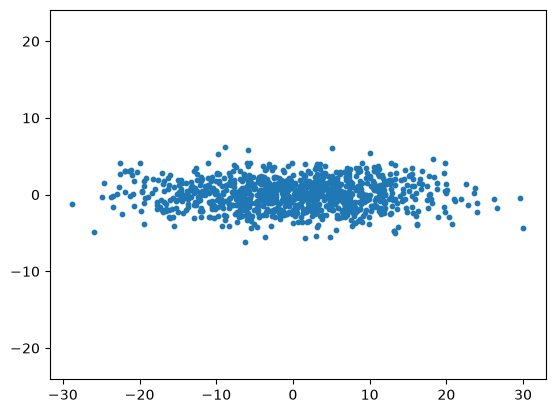

In [66]:
#project the data on the two first principal components
X_ellips_proj = pca_ellips.transform(X_ellips)
print('X_proj.shape:',X_ellips_proj.shape)

# Plot the projected data
plt.scatter(X_ellips_proj[:,0], X_ellips_proj[:,1], s=10)
plt.axis('equal')
plt.show()

## PCA for Swiss roll

### Prepare data

In [67]:
# Swiss roll data
mat_roll = scipy.io.loadmat('datasets/datasets/swiss_roll.mat')
X_roll = mat_roll['X']
Xref_roll = X_roll
n = X_roll.shape[0]
d = X_roll.shape[1]

print('n,d:',n,d)

n,d: 2048 3


In [68]:
Cgt_roll = mat_roll['Cgt'].squeeze()
Ccolor_roll = ['rgb('+str(c[0]*255)+', '+str(c[1]*255)+', '+str(c[2]*255)+')' for c in Cgt_roll]

### Run PCA

- 2D projection

In [69]:
# Compute PCA
pca_2_roll = PCA(n_components=2)
pca_2_roll.fit(X_roll)
print('pca.singular_values_:',pca_2_roll.singular_values_)

#project the data on the two first principal components
XRes2D_roll = pca_2_roll.transform(X_roll)
print('X_proj.shape:',XRes2D_roll.shape)


pca.singular_values_: [329.49279111 246.21949484]
X_proj.shape: (2048, 2)


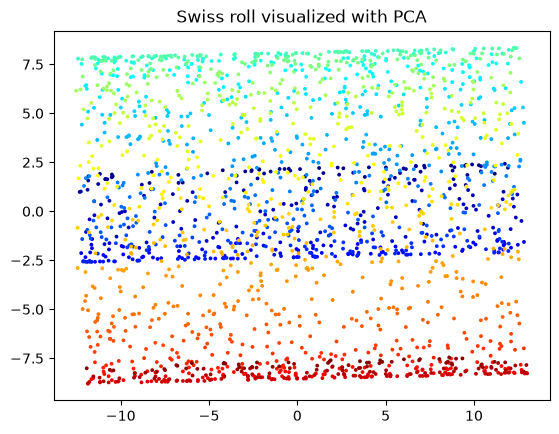

In [70]:
# plot
plt.figure()
plt.scatter(XRes2D_roll[:,0], XRes2D_roll[:,1], c=Cgt_roll, s=3, color=pyplot.jet())
plt.title('Swiss roll visualized with PCA') 
plt.show()

- 3D projection

In [71]:
# Compute PCA
pca_3_roll = PCA(n_components=3)
pca_3_roll.fit(X_roll)
print('pca.singular_values_:',pca_3_roll.singular_values_)

#project the data on the two first principal components
XRes3D_roll = pca_3_roll.transform(X_roll)
print('X_proj.shape:',XRes3D_roll.shape)

pca.singular_values_: [329.49279111 246.21949484 202.43246181]
X_proj.shape: (2048, 3)


In [72]:
# 3D Plot
Xvis, Yvis, Zvis = XRes3D_roll[:,0], XRes3D_roll[:,1], XRes3D_roll[:,2]
data = go.Scatter3d(x=Xvis, y=Yvis, z=Zvis, mode='markers', marker=dict(size=3, color=Ccolor_roll, colorscale='jet', opacity=1)) # data as points
fig = go.Figure(data=[data]) 
fig.update_layout(margin=dict(l=0, r=0, b=0, t=30, pad=0)) # tight layout but t=25 required for showing title 
fig.update_layout(autosize=False, width=600, height=600, title_text="Swiss roll visualized with PCA") # figure size and title
fig.update_layout(scene = dict(zaxis = dict(showgrid = True, showticklabels = False), zaxis_title = ' ') ) # no range values, no axis name, grid on
fig.update_layout(scene = dict(yaxis = dict(showgrid = True, showticklabels = False), yaxis_title = ' ') ) # no range values, no axis name, grid on
fig.update_layout(scene = dict(xaxis = dict(showgrid = True, showticklabels = False), xaxis_title = ' ') ) # no range values, no axis name, grid on
fig.layout.scene.aspectratio = {'x':1, 'y':1, 'z':1}
fig.show()

## PCA for MNIST

### Prepare data

In [73]:
mat_mnist = scipy.io.loadmat('datasets/datasets/MNIST_data.mat')
X_mnist = Xref_minst = mat_mnist['X']
# get only the first samples
nb_samples = X_mnist.shape[0]
X_mnist = X_mnist[:nb_samples,:]
n = X_mnist.shape[0]
d = X_mnist.shape[1]
C_mnist = Cgt_mnist = mat_mnist['C'].squeeze()
Cgt_mnist = Cgt_mnist[:nb_samples]

### Run PCA

- 2D projection

In [74]:
# Compute PCA
pca_2_mnist = PCA(n_components=2)
pca_2_mnist.fit(X_mnist)
print('pca.singular_values_:',pca_2_mnist.singular_values_)

#project the data on the two first principal components
XRes2D_minst = pca_2_mnist.transform(X_mnist)
print('X_proj.shape:',XRes2D_minst.shape)

pca.singular_values_: [141291.00226882 120817.18859621]
X_proj.shape: (60000, 2)


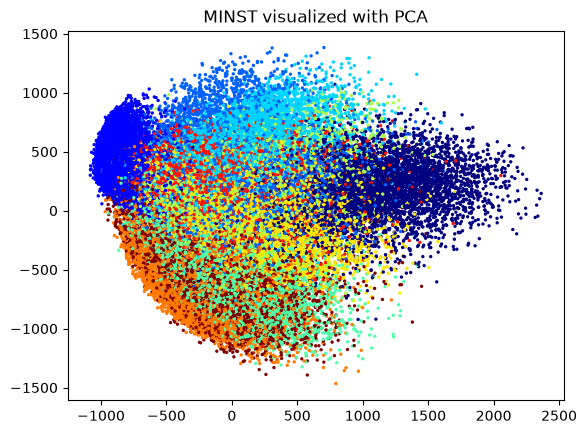

In [75]:
# plot
plt.figure()
plt.scatter(XRes2D_minst[:,0], XRes2D_minst[:,1], c=Cgt_mnist, s=2, color=pyplot.jet())
plt.title('MINST visualized with PCA') 
plt.show()

- 3D projection

In [76]:
# Compute PCA
pca_3_mnist = PCA(n_components=3)
pca_3_mnist.fit(X_mnist)
print('pca.singular_values_:',pca_3_mnist.singular_values_)

#project the data on the two first principal components
XRes3D_mnist = pca_3_mnist.transform(X_mnist)
print('X_proj.shape:',XRes3D_mnist.shape)

pca.singular_values_: [141291.00226882 120817.18859621 112650.9232813 ]
X_proj.shape: (60000, 3)


In [77]:
# 3D Plot
Xvis, Yvis, Zvis = XRes3D_mnist[:,0], XRes3D_mnist[:,1], XRes3D_mnist[:,2]
data = go.Scatter3d(x=Xvis, y=Yvis, z=Zvis, mode='markers', marker=dict(size=2, color=Cgt_mnist, colorscale='jet', opacity=1)) # data as points
fig = go.Figure(data=[data]) 
fig.update_layout(margin=dict(l=0, r=0, b=0, t=30, pad=0)) # tight layout but t=25 required for showing title 
fig.update_layout(autosize=False, width=600, height=600, title_text="MINST visualized with PCA") # figure size and title
fig.update_layout(scene = dict(zaxis = dict(showgrid = True, showticklabels = False), zaxis_title = ' ') ) # no range values, no axis name, grid on
fig.update_layout(scene = dict(yaxis = dict(showgrid = True, showticklabels = False), yaxis_title = ' ') ) # no range values, no axis name, grid on
fig.update_layout(scene = dict(xaxis = dict(showgrid = True, showticklabels = False), xaxis_title = ' ') ) # no range values, no axis name, grid on
fig.layout.scene.aspectratio = {'x':1, 'y':1, 'z':1}
fig.show()